# Sentiment Analysis with BERT Embeddings & Multinomial Logistic Regression

This notebook implements a complete ML pipeline for sentiment classification:
1. Data Loading
2. Exploratory Data Analysis (EDA) - All Dashboard Analysis + N-gram Analysis
3. Preprocessing (label mapping to positive, negative, neutral)
4. Feature Engineering (BERT embeddings from Transformers)
5. Model Training (Multinomial Logistic Regression)
6. Model Evaluation

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
import os
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

OUTPUT_DIR = 'artifacts/eda'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading

In [2]:
data_path = 'artificats/raw/sentimentdataset.csv'
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (732, 15)

Column Names: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("="*50)
print("BASIC STATISTICS")
print("="*50)
print("\nDataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSentiment Value Counts (Original):")
print(df['Sentiment'].value_counts())

BASIC STATISTICS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB

Missing Values:
Unnamed: 0.1    0
Unnamed: 0      0
Text            

### 2.1 Sentiment Distribution

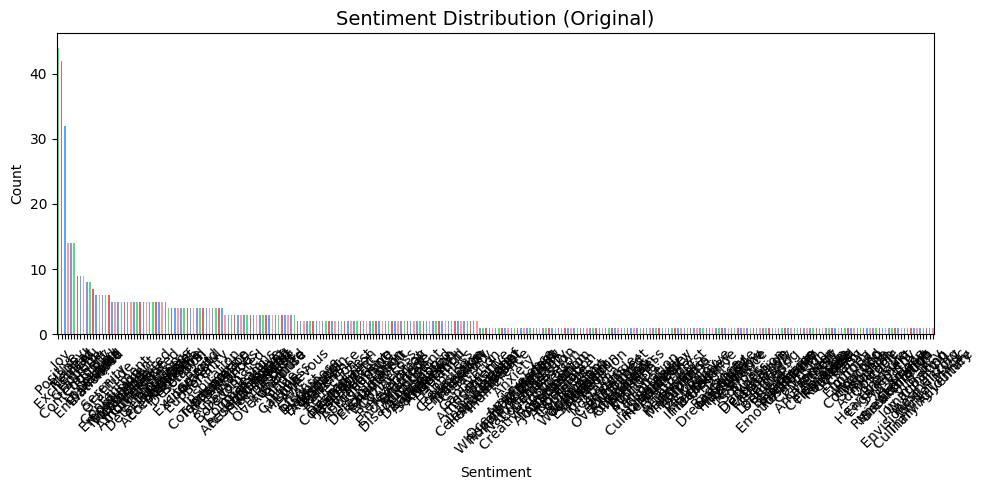

Saved: artifacts/eda/sentiment_distribution.png


In [4]:
plt.figure(figsize=(10, 5))
df['Sentiment'].value_counts().plot(kind='bar', color=['#43e97b', '#f5576c', '#4facfe', '#ff9a9e', '#a18cd1'])
plt.title('Sentiment Distribution (Original)', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentiment_distribution.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/sentiment_distribution.png")

### 2.2 Text Length Analysis

Text Length Statistics:
Average: 87.60
Max: 157
Min: 50


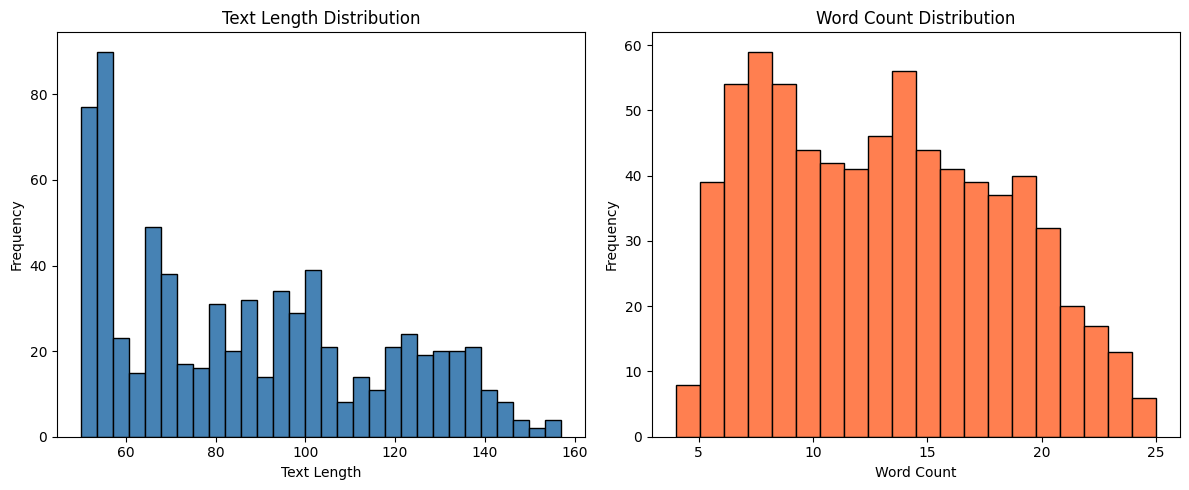

Saved: artifacts/eda/text_length_analysis.png


In [5]:
df['text_length'] = df['Text'].apply(lambda x: len(str(x)))
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

print("Text Length Statistics:")
print(f"Average: {df['text_length'].mean():.2f}")
print(f"Max: {df['text_length'].max()}")
print(f"Min: {df['text_length'].min()}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=30, color='steelblue', edgecolor='black')
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['word_count'], bins=20, color='coral', edgecolor='black')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/text_length_analysis.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/text_length_analysis.png")

### 2.3 Platform vs Sentiment Analysis

<Figure size 1200x600 with 0 Axes>

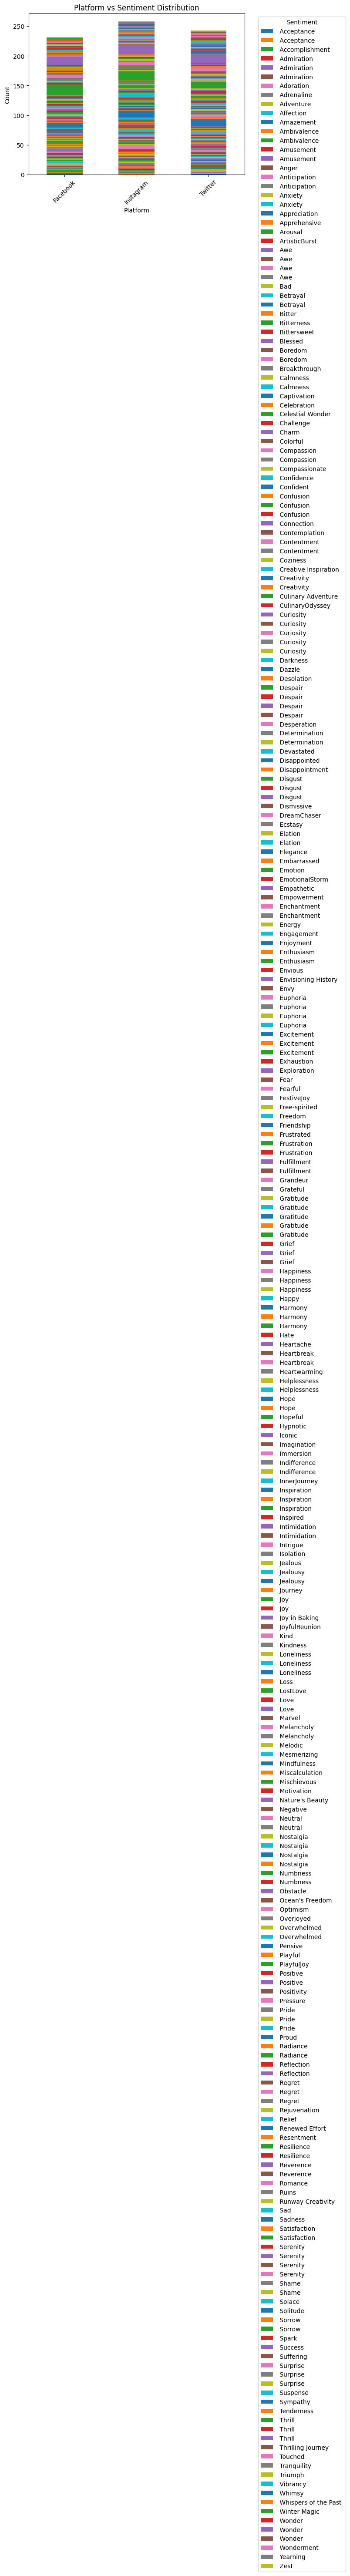

Saved: artifacts/eda/platform_sentiment.png

Platform Distribution:
Platform
Instagram     258
Facebook      231
Twitter       128
Twitter       115
Name: count, dtype: int64


In [6]:
if 'Platform' in df.columns:
    plt.figure(figsize=(12, 6))
    platform_sentiment = pd.crosstab(df['Platform'].str.strip(), df['Sentiment'])
    platform_sentiment.plot(kind='bar', stacked=True)
    plt.title('Platform vs Sentiment Distribution')
    plt.xlabel('Platform')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/platform_sentiment.png', dpi=150)
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/platform_sentiment.png")
    print("\nPlatform Distribution:")
    print(df['Platform'].value_counts())

### 2.4 Sentiment Trend Over Time

<Figure size 1200x600 with 0 Axes>

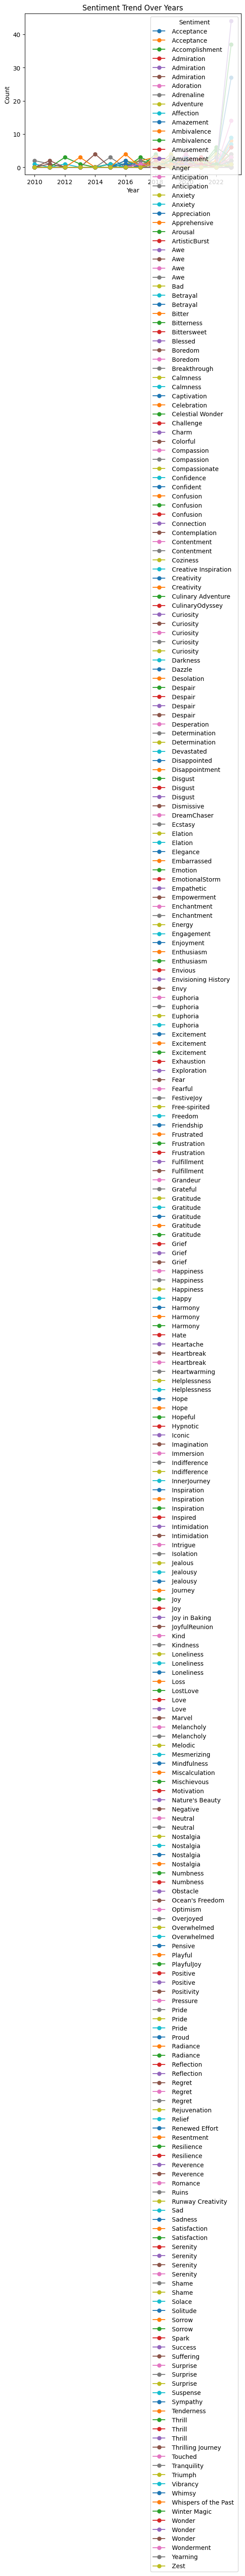

Saved: artifacts/eda/sentiment_trend_yearly.png

Yearly Distribution:
Sentiment  Acceptance     Acceptance        Accomplishment   Admiration   \
Year                                                                       
2010                   0                 0                0            0   
2011                   0                 0                0            0   
2012                   0                 0                0            0   
2013                   0                 0                0            0   
2014                   0                 0                0            0   
2015                   0                 0                0            0   
2016                   0                 0                0            0   
2017                   0                 0                0            0   
2018                   0                 0                0            0   
2019                   0                 0                0            0   
2020              

In [7]:
if 'Year' in df.columns:
    plt.figure(figsize=(12, 6))
    yearly_trend = df.groupby(['Year', 'Sentiment']).size().unstack(fill_value=0)
    yearly_trend.plot(kind='line', marker='o')
    plt.title('Sentiment Trend Over Years')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sentiment_trend_yearly.png', dpi=150)
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/sentiment_trend_yearly.png")
    print("\nYearly Distribution:")
    print(yearly_trend)

### 2.5 Country Analysis

<Figure size 1200x600 with 0 Axes>

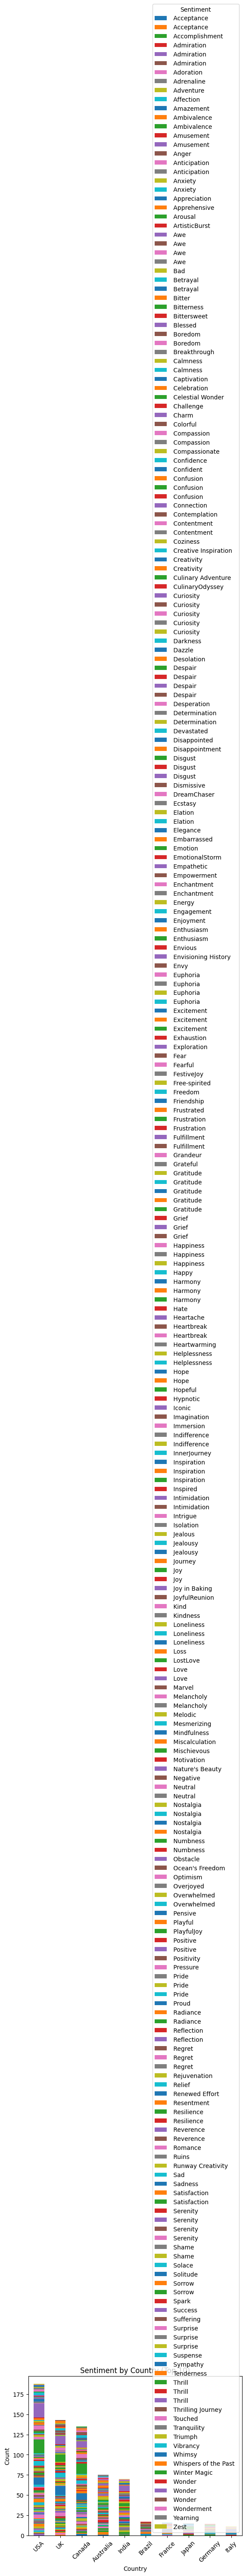

Saved: artifacts/eda/country_sentiment.png


In [8]:
if 'Country' in df.columns:
    plt.figure(figsize=(12, 6))
    country_sentiment = pd.crosstab(df['Country'].str.strip(), df['Sentiment'])
    top_countries = country_sentiment.sum(axis=1).nlargest(10)
    country_sentiment.loc[top_countries.index].plot(kind='bar', stacked=True)
    plt.title('Sentiment by Country (Top 10)')
    plt.xlabel('Country')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/country_sentiment.png', dpi=150)
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/country_sentiment.png")

### 2.6 Top Keywords & Hashtags

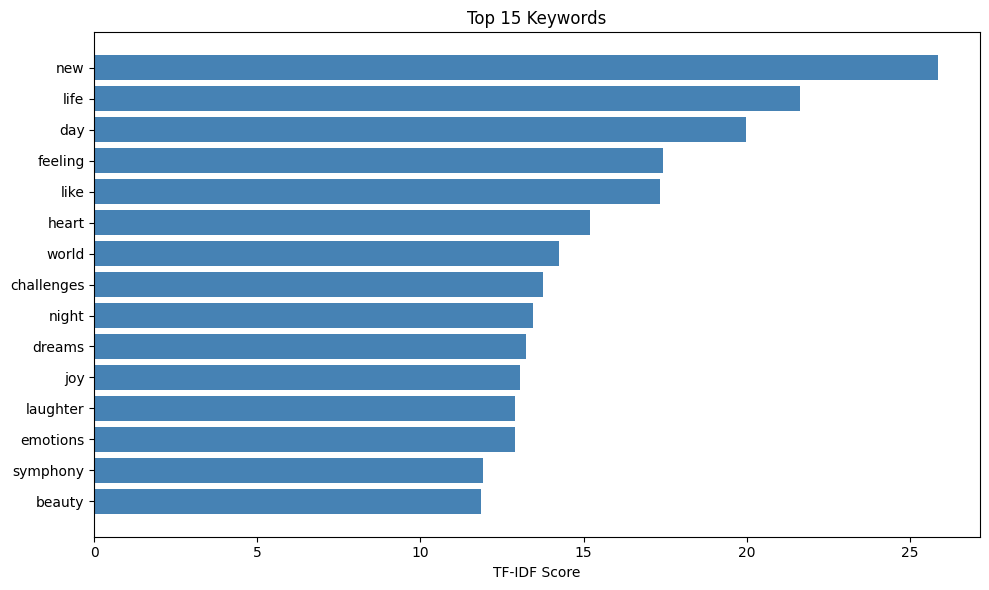

Saved: artifacts/eda/top_keywords.png


In [9]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(clean_text)

vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['clean_text'].fillna(''))
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1
keyword_scores = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 6))
keywords = [k for k, s in keyword_scores[:15]]
scores = [s for k, s in keyword_scores[:15]]
plt.barh(range(len(keywords)), scores, color='steelblue')
plt.yticks(range(len(keywords)), keywords)
plt.xlabel('TF-IDF Score')
plt.title('Top 15 Keywords')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_keywords.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/top_keywords.png")

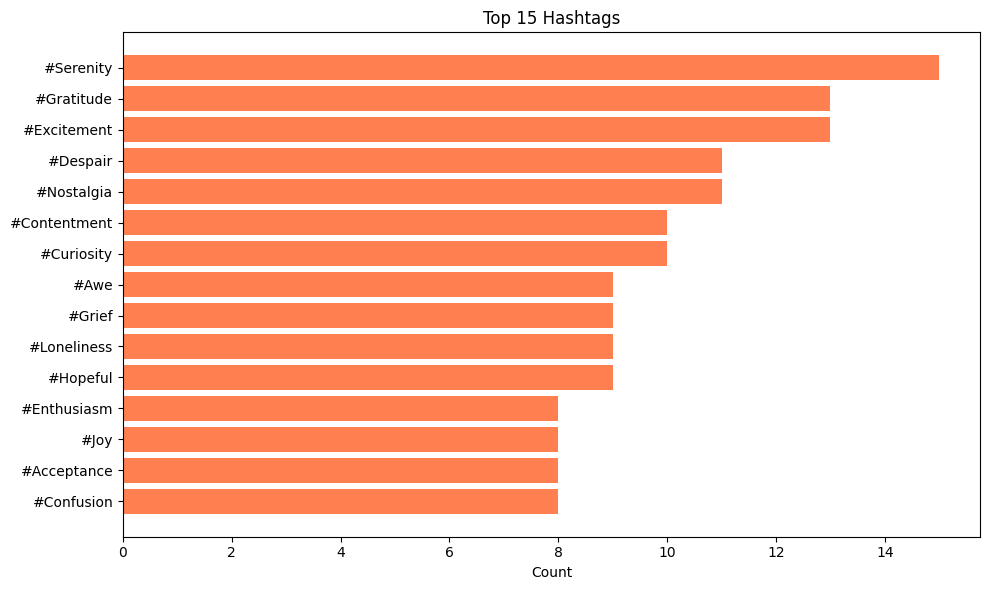

Saved: artifacts/eda/top_hashtags.png


In [10]:
if 'Hashtags' in df.columns:
    all_hashtags = []
    for tags in df['Hashtags'].dropna():
        if isinstance(tags, str):
            hashtags = re.findall(r'#(\w+)', tags)
            all_hashtags.extend(hashtags)
    
    hashtag_counts = Counter(all_hashtags).most_common(15)
    
    plt.figure(figsize=(10, 6))
    hashtags = [f"#{h}" for h, c in hashtag_counts]
    counts = [c for h, c in hashtag_counts]
    plt.barh(range(len(hashtags)), counts, color='coral')
    plt.yticks(range(len(hashtags)), hashtags)
    plt.xlabel('Count')
    plt.title('Top 15 Hashtags')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/top_hashtags.png', dpi=150)
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/top_hashtags.png")

### 2.7 Word Cloud Analysis by Sentiment

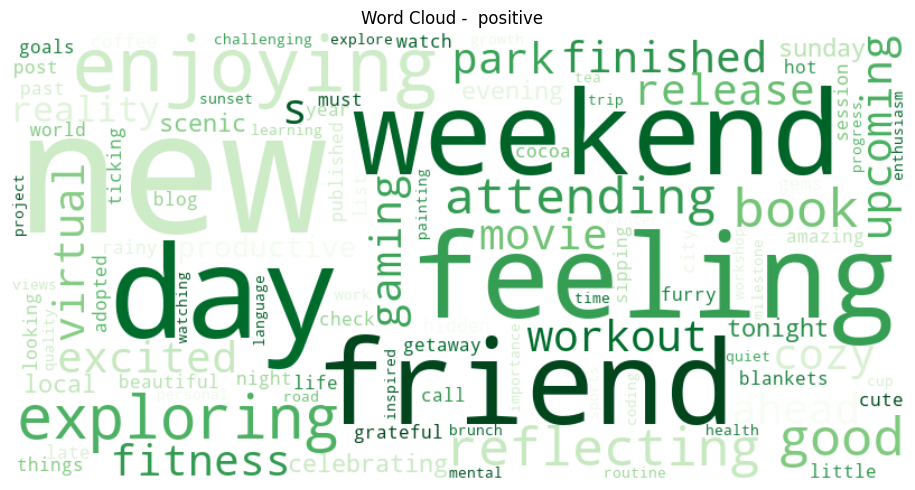

Saved: artifacts/eda/wordcloud_ positive  .png


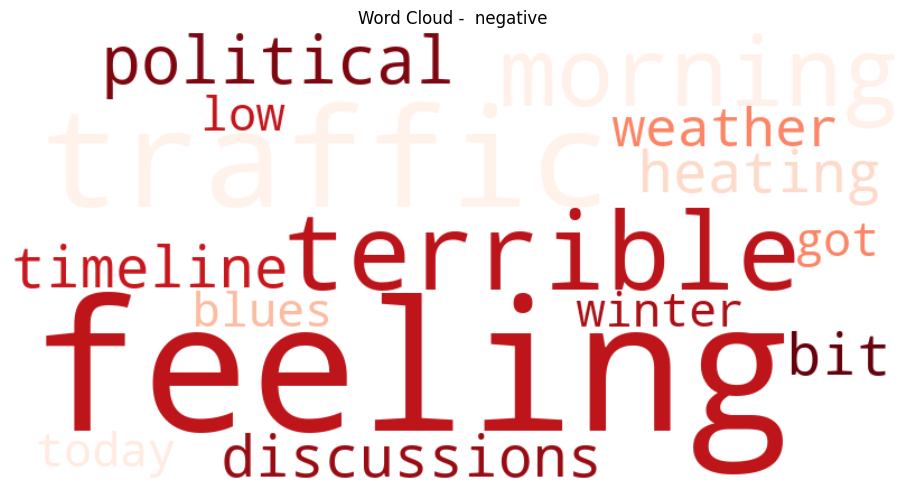

Saved: artifacts/eda/wordcloud_ negative  .png


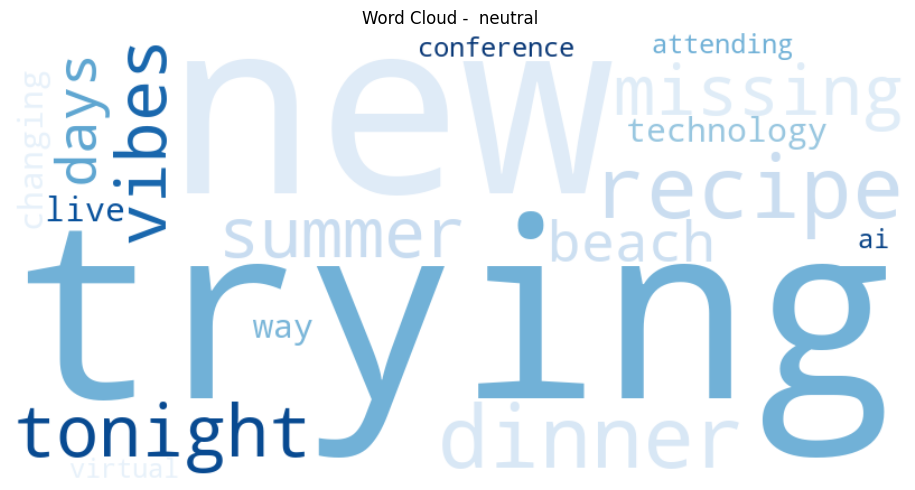

Saved: artifacts/eda/wordcloud_ neutral   .png


In [11]:
from wordcloud import WordCloud

def create_wordcloud(text_data, color, filename):
    text = ' '.join(text_data.dropna().astype(str))
    if len(text) < 1:
        return
    wc = WordCloud(width=800, height=400, background_color='white', 
                 colormap=color, max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {filename.split("_")[-1].capitalize()}')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}.png', dpi=150)
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/{filename}.png")

sentiments = df['Sentiment'].unique()
color_maps = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Blues'}
default_colors = ['Greens', 'Reds', 'Blues', 'Purples', 'Oranges']

for i, sentiment in enumerate(sentiments[:3]):
    sentiment_texts = df[df['Sentiment'] == sentiment]['clean_text']
    color = color_maps.get(sentiment, default_colors[i % len(default_colors)])
    create_wordcloud(sentiment_texts, color, f'wordcloud_{sentiment.lower()}')

### 2.8 N-gram Analysis

UNIGRAM ANALYSIS (1-gram)


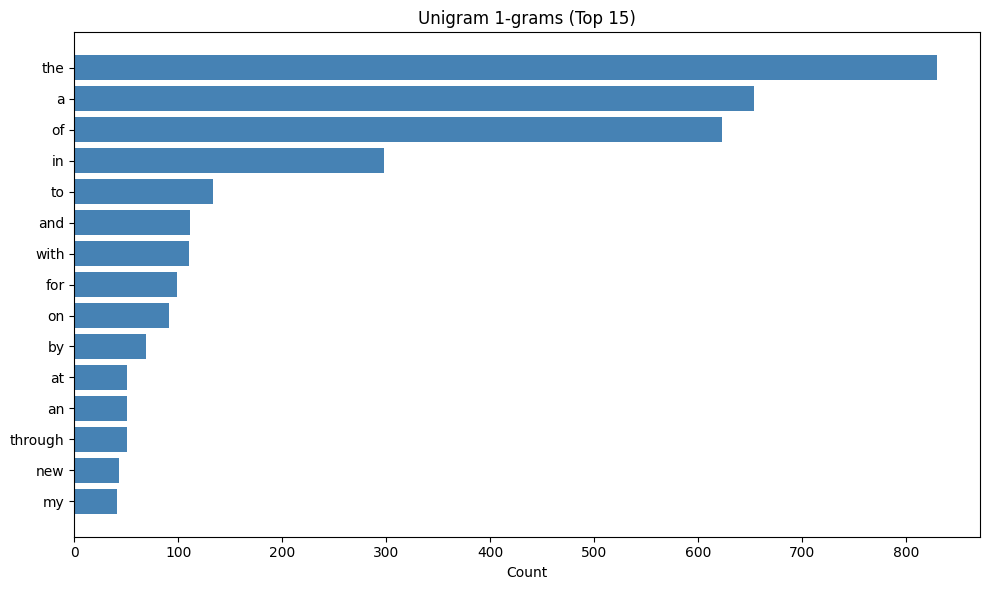

Saved: artifacts/eda/1gram_analysis.png


In [14]:
def get_ngrams(text, n):
    words = str(text).lower().split()
    return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

def plot_ngrams(n, top_n=15, title_prefix='Top'):
    all_ngrams = []
    for text in df['Text']:
        all_ngrams.extend(get_ngrams(text, n))
    
    ngram_counts = Counter(all_ngrams).most_common(top_n)
    ngrams, counts = zip(*ngram_counts)
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(ngrams)), counts, color='steelblue')
    plt.yticks(range(len(ngrams)), ngrams)
    plt.xlabel('Count')
    plt.title(f'{title_prefix} {n}-grams (Top {top_n})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    filename = f'{n}gram_analysis.png'
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/{filename}")
    
    return ngram_counts

print("="*50)
print("UNIGRAM ANALYSIS (1-gram)")
print("="*50)
unigrams = plot_ngrams(1, 15, 'Unigram')

BIGRAM ANALYSIS (2-gram)


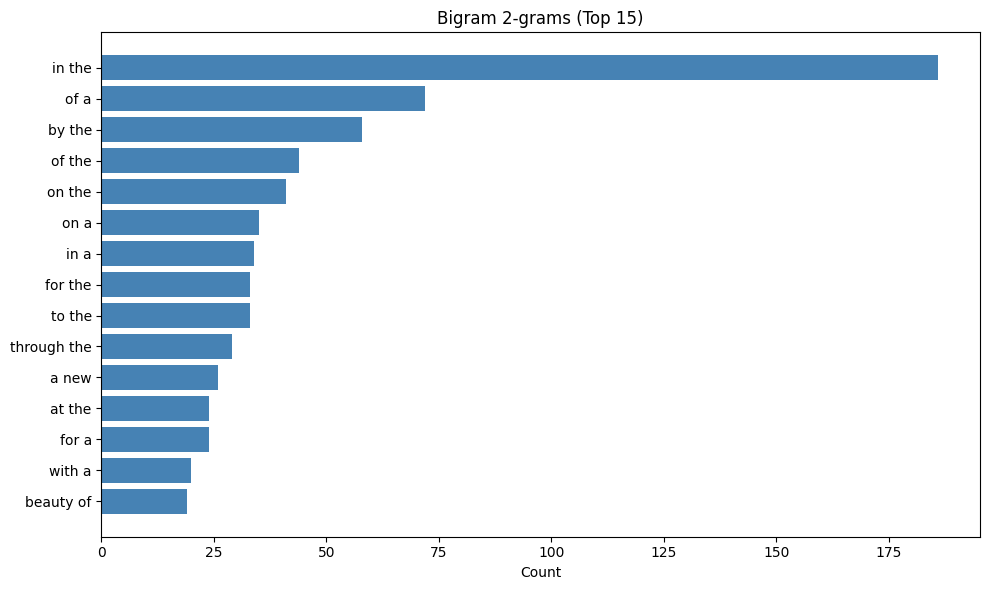

Saved: artifacts/eda/2gram_analysis.png


In [15]:
print("="*50)
print("BIGRAM ANALYSIS (2-gram)")
print("="*50)
bigrams = plot_ngrams(2, 15, 'Bigram')

TRIGRAM ANALYSIS (3-gram)


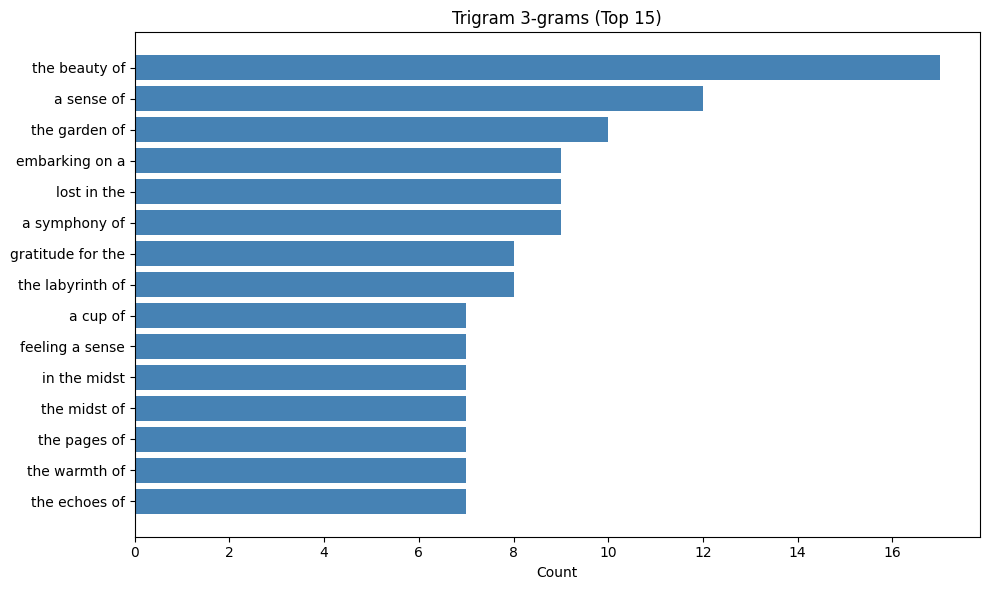

Saved: artifacts/eda/3gram_analysis.png


In [16]:
print("="*50)
print("TRIGRAM ANALYSIS (3-gram)")
print("="*50)
trigrams = plot_ngrams(3, 15, 'Trigram')

N-GRAM BY SENTIMENT


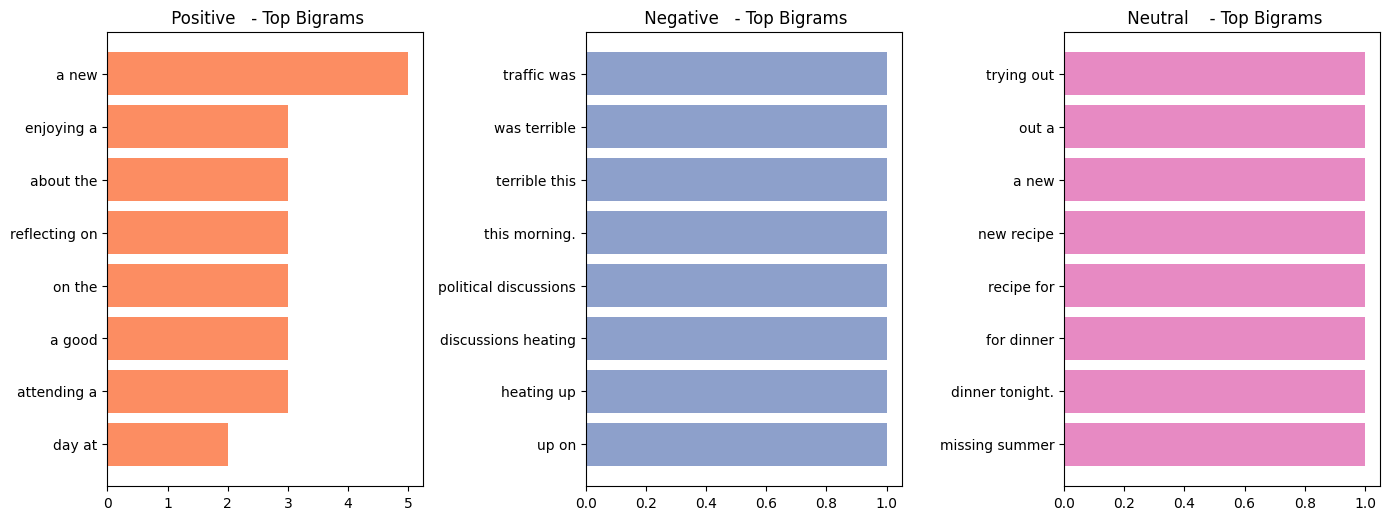

Saved: artifacts/eda/ngram_by_sentiment.png


In [17]:
print("="*50)
print("N-GRAM BY SENTIMENT")
print("="*50)

plt.figure(figsize=(14, 10))
sentiments = df['Sentiment'].unique()

for idx, sentiment in enumerate(sentiments[:3], 1):
    sentiment_df = df[df['Sentiment'] == sentiment]
    all_bigrams = []
    for text in sentiment_df['Text']:
        all_bigrams.extend(get_ngrams(text, 2))
    
    bigram_counts = Counter(all_bigrams).most_common(8)
    
    plt.subplot(2, 3, idx)
    if bigram_counts:
        ngrams, counts = zip(*bigram_counts)
        plt.barh(range(len(ngrams)), counts, color=plt.cm.Set2(idx))
        plt.yticks(range(len(ngrams)), ngrams)
        plt.title(f'{sentiment} - Top Bigrams')
        plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ngram_by_sentiment.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/ngram_by_sentiment.png")

## 3. Preprocessing - Label Mapping

In [18]:
positive_labels = ['Positive', 'Happiness', 'Joy', 'Love', 'Amusement', 'Enjoyment', 'Admiration', 
               'Affection', 'Awe', 'Surprise', 'Adoration', 'Excitement', 'Anticipation',
               'Calmness', 'Contentment', 'Serenity', 'Gratitude', 'Hope', 'Empowerment',
               'Compassion', 'Tenderness', 'Enthusiasm', 'Fulfillment', 'Elation', 
               'Euphoria', 'Pride', 'Kind', 'Acceptance', 'Curiosity', 'Determination']

negative_labels = ['Negative', 'Anger', 'Fear', 'Sadness', 'Disgust', 'Disappointed',
                 'Bitter', 'Confusion', 'Frustration', 'Shame', 'Jealousy', 'Resentment',
                 'Boredom', 'Anxiety', 'Intimidation', 'Helplessness', 'Envy', 'Regret',
                 'Despair', 'Grief', 'Loneliness', 'Numbness', 'Melancholy', 'Ambivalence',
                 'Indifference', 'Nostalgia']

neutral_labels = ['Neutral', 'Confusion', 'Curiosity', 'Indifference', 'Numbness',
               'Contentment', 'Acceptance']

def map_sentiment(label):
    label = str(label).strip()
    if label in positive_labels:
        return 'positive'
    elif label in negative_labels:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_mapped'] = df['Sentiment'].apply(map_sentiment)

print("Mapped Sentiment Distribution:")
print(df['sentiment_mapped'].value_counts())

Mapped Sentiment Distribution:
sentiment_mapped
positive    305
neutral     302
negative    125
Name: count, dtype: int64


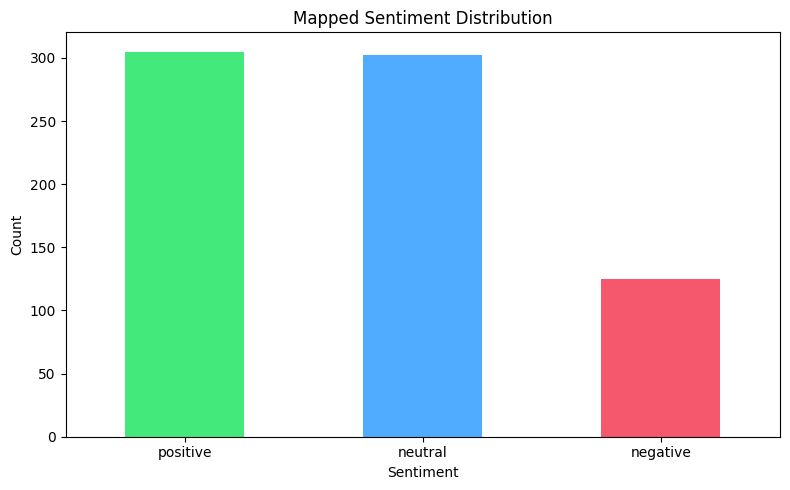

Saved: artifacts/eda/sentiment_mapped_distribution.png


In [19]:
plt.figure(figsize=(8, 5))
colors = {'positive': '#43e97b', 'negative': '#f5576c', 'neutral': '#4facfe'}
df['sentiment_mapped'].value_counts().plot(kind='bar', color=[colors.get(x, 'gray') for x in df['sentiment_mapped'].value_counts().index])
plt.title('Mapped Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentiment_mapped_distribution.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/sentiment_mapped_distribution.png")

## 4. Feature Engineering - BERT Embeddings

In [20]:
from transformers import BertTokenizer, BertModel
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.to(device)
model.eval()

print("BERT model loaded successfully!")

Using device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3156.34it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded successfully!


In [21]:
def get_bert_embeddings(texts, tokenizer, model, device, batch_size=32, max_length=128):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
            input_ids = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embeddings)
            if (i + batch_size) % 100 == 0:
                print(f"Processed {min(i + batch_size, len(texts))}/{len(texts)} texts")
    return np.array(embeddings)

texts = df['Text'].tolist()
print(f"Generating BERT embeddings for {len(texts)} texts...")

Generating BERT embeddings for 732 texts...


In [22]:
embeddings = get_bert_embeddings(texts, tokenizer, model, device, batch_size=32)
print(f"\nEmbeddings shape: {embeddings.shape}")
np.save('bert_embeddings.npy', embeddings)
print("BERT embeddings saved to 'bert_embeddings.npy'")


Embeddings shape: (732, 768)
BERT embeddings saved to 'bert_embeddings.npy'


## 5. Model Training - Multinomial Logistic Regression

In [23]:
X = embeddings
y = np.array(df['sentiment_mapped'].tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set distribution:")
print(pd.Series(y_train).value_counts())

Training set size: 585
Test set size: 147

Training set distribution:
positive    244
neutral     241
negative    100
Name: count, dtype: int64


In [24]:
print("Training Multinomial Logistic Regression...")
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)
print("Model training completed!")

Training Multinomial Logistic Regression...
Model training completed!


## 6. Model Evaluation

In [25]:
y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7075

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.44      0.54        25
     neutral       0.71      0.66      0.68        61
    positive       0.71      0.87      0.78        61

    accuracy                           0.71       147
   macro avg       0.70      0.65      0.67       147
weighted avg       0.71      0.71      0.70       147



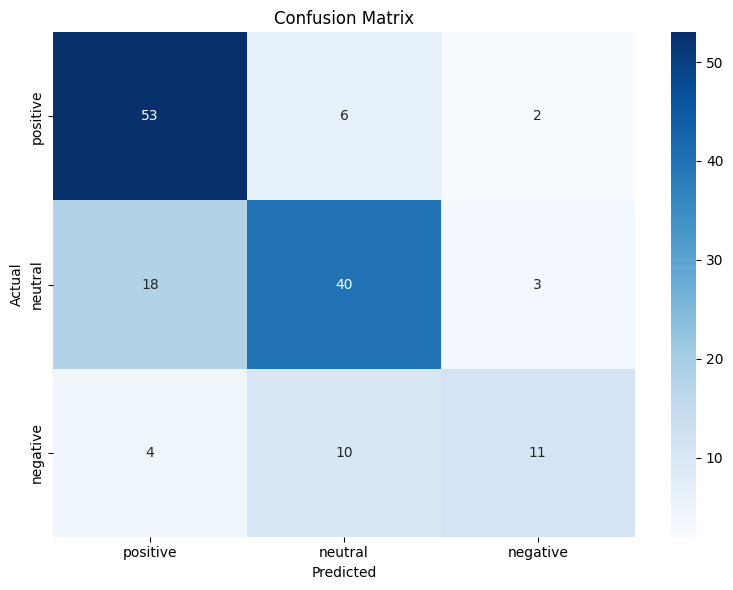

Saved: artifacts/eda/confusion_matrix.png


In [26]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/confusion_matrix.png")

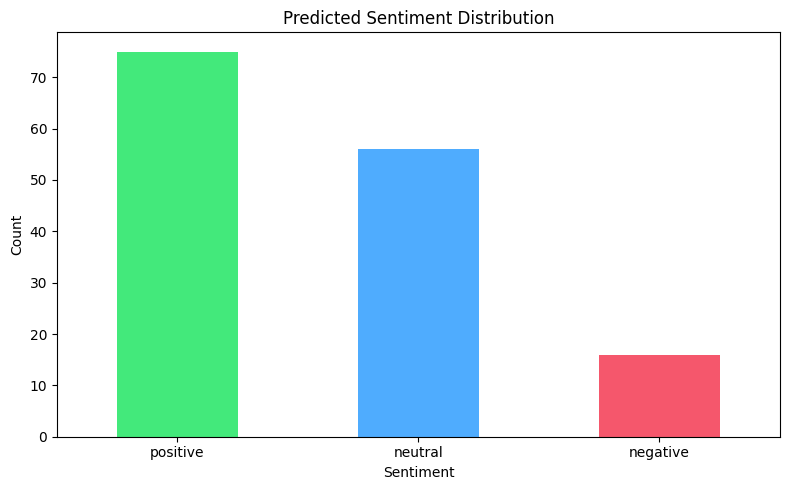

Saved: artifacts/eda/predicted_distribution.png


In [27]:
plt.figure(figsize=(8, 5))
pd.Series(y_pred).value_counts().plot(kind='bar', color=['#43e97b', '#4facfe', '#f5576c'])
plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/predicted_distribution.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/predicted_distribution.png")

## Summary

In [31]:
print("="*50)
print("PIPELINE COMPLETE")
print("="*50)
print("\nAll EDA visualizations saved to:", OUTPUT_DIR)
print("\nFiles created:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  - {f}")

PIPELINE COMPLETE

All EDA visualizations saved to: artifacts/eda

Files created:
  - 1gram_analysis.png
  - 2gram_analysis.png
  - 3gram_analysis.png
  - confusion_matrix.png
  - country_sentiment.png
  - ngram_by_sentiment.png
  - platform_sentiment.png
  - predicted_distribution.png
  - sentiment_distribution.png
  - sentiment_mapped_distribution.png
  - sentiment_trend_yearly.png
  - text_length_analysis.png
  - top_hashtags.png
  - top_keywords.png
  - wordcloud_ negative  .png
  - wordcloud_ neutral   .png
  - wordcloud_ positive  .png
  - wordcloud_negative.png
  - wordcloud_neutral.png
  - wordcloud_positive.png
